/home/renzo/TC2_renzo/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


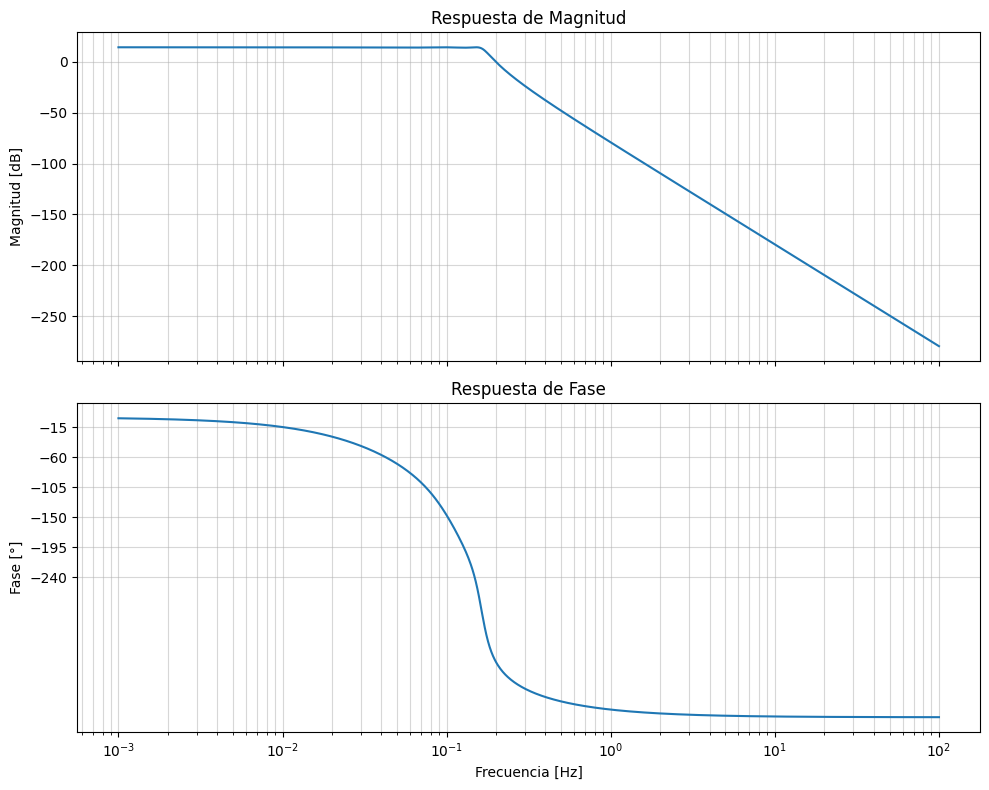

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

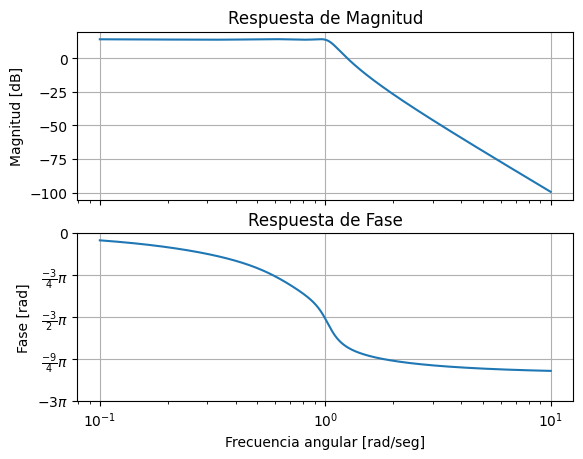

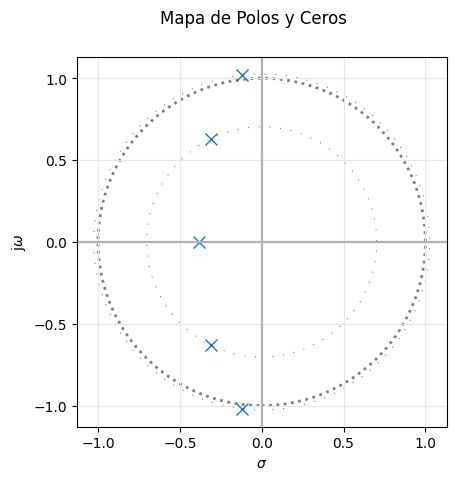

In [8]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Ganancia total
K = 1.05361 * 0.994592

num = np.array([0, 0, K])

# Denominadores individuales
den1 = np.array([1, 0.238649, 1.05361])
den2 = np.array([1, 0.62478, 0.494592])
den3 = np.array([1, 0.386136])

# Producto de polinomios
den = np.polymul(np.polymul(den1, den2), den3)

# Transferencia
T = TransferFunction(num, den)


f = np.logspace(-3, 2, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Gráfico de Magnitud
ax_mag.semilogx(f, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-240, 181, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(f, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia [Hz]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

bodePlot(T, fig_id=1)
pzmap(T)

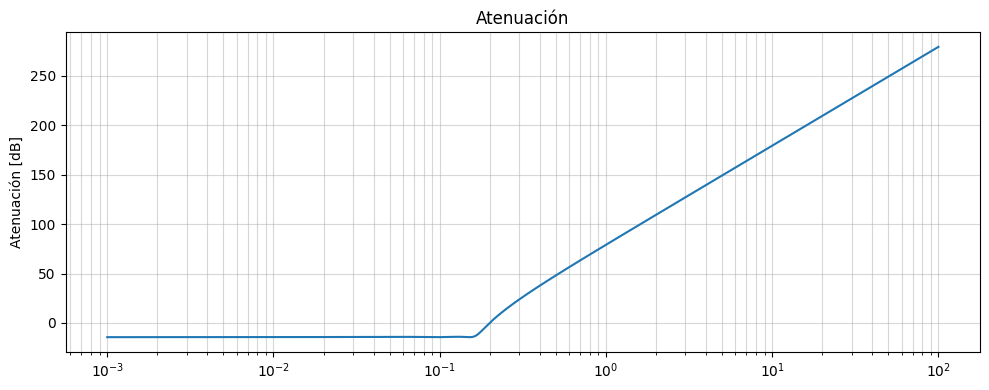

In [9]:
attenuation_db = -mag

fig, (ax_mag) = plt.subplots(figsize=(10, 4), sharex=True)


# Gráfico de Atenuación
ax_mag.semilogx(f, attenuation_db)
ax_mag.set_title('Atenuación')
ax_mag.set_ylabel('Atenuación [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()